# LLM Router — Benchmark Dataset Analysis
**Supabase: `benchmark_results` table**

Covers:
- Dataset size & coverage
- Use case / complexity / clarity distributions
- Model & provider breakdown
- Accuracy score distributions (legacy vs multi-evaluator)
- Per-model accuracy, cost, latency comparison
- Multi-evaluator agreement & conflict analysis
- Cost vs accuracy vs latency trade-off scatter
- Data quality audit (nulls, placeholders, low-confidence rows)
- KNN coverage (prompt_embeddings vs benchmark_results)

In [ ]:
# ── 0. Installs (run once) ────────────────────────────────────────────────────
!pip install supabase python-dotenv pandas matplotlib seaborn plotly kaleido

In [1]:
# ── 1. Setup ──────────────────────────────────────────────────────────────────
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from supabase import create_client

warnings.filterwarnings('ignore')

# Load env from backend/.env
env_path = Path("../backend/.env")
load_dotenv(env_path)

# Style
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#3a3d4e',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#b0b0b0',
    'ytick.color':      '#b0b0b0',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2d3e',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'figure.titlesize': 15,
})

PALETTE    = ['#6c63ff', '#00d4aa', '#ff6b6b', '#ffd166', '#06d6a0', '#118ab2', '#ef476f', '#ffc8dd']
ACCENT     = '#6c63ff'
GOOD_COLOR = '#00d4aa'
WARN_COLOR = '#ffd166'
BAD_COLOR  = '#ff6b6b'

print('✓ Setup complete')

✓ Setup complete


In [2]:
# ── 2. Load Data from Supabase ────────────────────────────────────────────────
sb = create_client(os.getenv('SUPABASE_URL'), os.getenv('SUPABASE_KEY'))

COLUMNS = (
    'id,model_id,provider,use_case,prompt_complexity,clarity,'
    'accuracy_score,avg_accuracy_score,'
    'eval_llama4_maverick_score,eval_mistral_large_score,'
    'eval_nova_premier_score,eval_deepseek_r1_score,'
    'eval_conflict_flag,high_conflict_flag,low_confidence,'
    'confidence_level,eval_count,'
    'cost,tokens,latency_ms,prompt_hash,created_at'
)

def fetch_all(query, page=1000):
    rows, start = [], 0
    while True:
        batch = query.range(start, start + page - 1).execute().data or []
        rows.extend(batch)
        if len(batch) < page: break
        start += page
    return rows

print('Fetching benchmark_results...')
raw = fetch_all(sb.table('benchmark_results').select(COLUMNS))
df  = pd.DataFrame(raw)

# Also fetch prompt_embeddings count
emb_count = sb.table('prompt_embeddings').select('id', count='exact').execute().count

print(f'✓ Loaded {len(df):,} rows  |  {emb_count} embeddings in prompt_embeddings')
df.head(3)

Fetching benchmark_results...
✓ Loaded 8,594 rows  |  549 embeddings in prompt_embeddings


,id,model_id,provider,use_case,prompt_complexity,clarity,accuracy_score,avg_accuracy_score,eval_llama4_maverick_score,eval_mistral_large_score,...,eval_conflict_flag,high_conflict_flag,low_confidence,confidence_level,eval_count,cost,tokens,latency_ms,prompt_hash,created_at
0,2cc4c15a-2e41-4a68-aa1f-8e02760feac4,nova-pro,Amazon,reasoning,mid,CLEAR,100,95.00,95.0,NaN,...,False,False,False,1.00,2.0,0.001580,541,3294,bbe9f78b055b2b5aa3cbefb00a14e025,2026-03-26T18:43:58.319678+00:00
1,a9ccc879-21cd-49a6-a188-6d50e0762925,llama4-maverick,Meta,text-generation,low,CLEAR,95,97.67,100.0,95.0,...,False,False,False,0.95,3.0,0.000066,107,14864,7f34e02e9f6159e0d8eba37273b48040,2026-03-25T17:13:33.994263+00:00
2,fec4d235-4fe3-46ee-8dc4-8572ad552f69,gemini-3-1-pro,Google,code-generation,mid,CLEAR,92,95.00,95.0,95.0,...,False,False,False,1.00,2.0,0.009094,926,22680,02529ca367ce247fcdc2b73708417f15,2026-03-26T17:50:23.475811+00:00


In [3]:
# ── 3. Clean & Cast ───────────────────────────────────────────────────────────
numeric_cols = [
    'accuracy_score','avg_accuracy_score',
    'eval_llama4_maverick_score','eval_mistral_large_score',
    'eval_nova_premier_score','eval_deepseek_r1_score',
    'confidence_level','eval_count',
    'cost','tokens','latency_ms'
]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

bool_cols = ['eval_conflict_flag','high_conflict_flag','low_confidence']
for c in bool_cols:
    if c in df.columns:
        df[c] = df[c].map({True: True, False: False, 'true': True, 'false': False}).astype('boolean')

df['created_at']        = pd.to_datetime(df['created_at'], errors='coerce')
df['prompt_complexity'] = df['prompt_complexity'].str.lower().str.strip()
df['clarity']           = df['clarity'].str.upper().str.strip()
df['use_case']          = df['use_case'].str.lower().str.strip()

# Primary accuracy signal: prefer avg_accuracy_score
df['primary_accuracy'] = df['avg_accuracy_score'].combine_first(df['accuracy_score'])

# Flag legacy-only rows
df['has_multi_eval']   = df['avg_accuracy_score'].notna()
df['has_prompt_hash']  = df['prompt_hash'].notna()
df['latency_s']        = df['latency_ms'] / 1000
df['cost_per_1k']      = df['cost'] * 1000

print(f'Shape: {df.shape}')
print(f'\nColumn dtypes:')
print(df[['model_id','provider','use_case','prompt_complexity','clarity',
          'primary_accuracy','cost','latency_ms']].dtypes)

Shape: (8594, 27)

Column dtypes:
model_id              object
provider              object
use_case              object
prompt_complexity     object
clarity               object
primary_accuracy     float64
cost                 float64
latency_ms             int64
dtype: object


---
## Section 1 — Dataset Overview

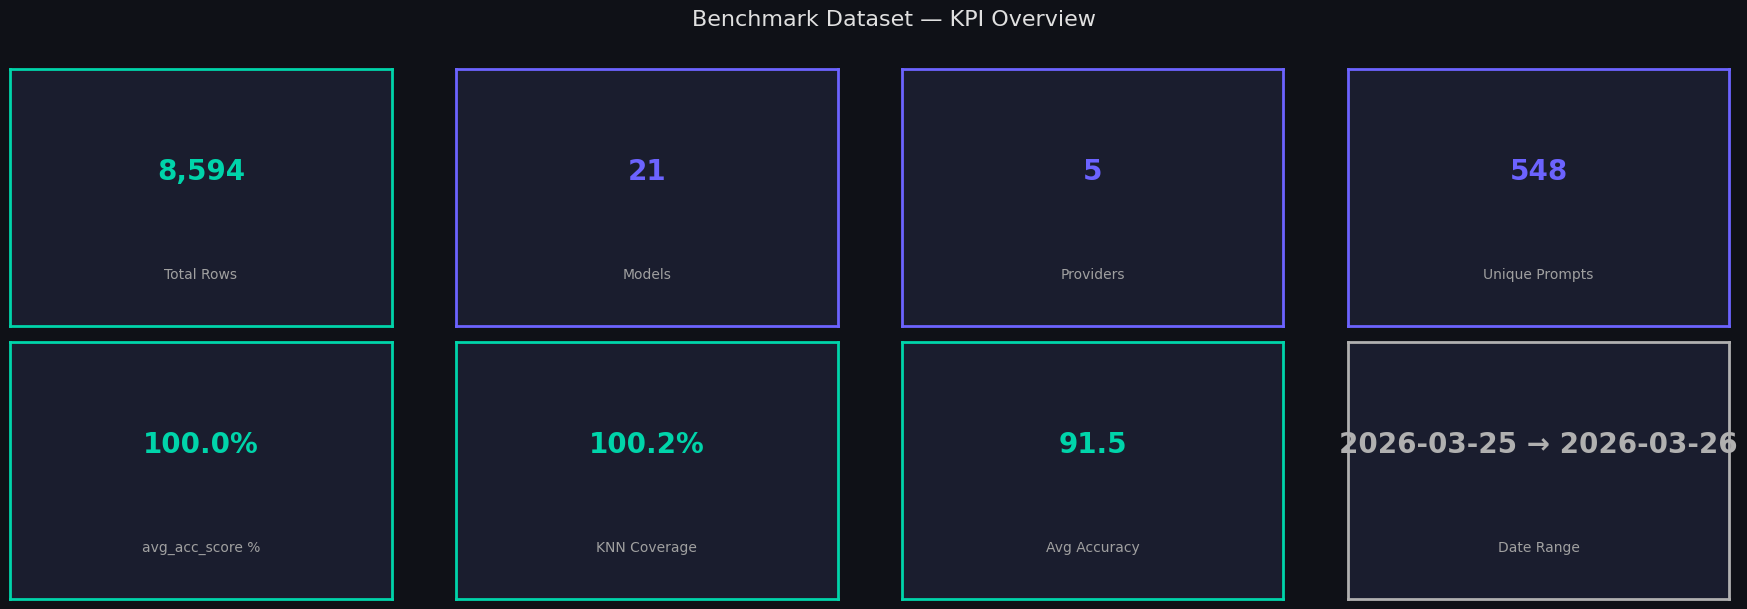

In [4]:
# ── 4. Overview KPI Cards ─────────────────────────────────────────────────────
unique_models    = df['model_id'].nunique()
unique_providers = df['provider'].nunique()
unique_prompts   = df['prompt_hash'].nunique()
pct_multi_eval   = df['has_multi_eval'].mean() * 100
pct_hash         = df['has_prompt_hash'].mean() * 100
knn_coverage     = emb_count / max(unique_prompts, 1) * 100
avg_acc          = df['primary_accuracy'].mean()
date_range       = f"{df['created_at'].min().date()} → {df['created_at'].max().date()}"

fig, axes = plt.subplots(2, 4, figsize=(18, 6))
fig.suptitle('Benchmark Dataset — KPI Overview', fontsize=16, y=1.01)

kpis = [
    ('Total Rows',       f'{len(df):,}',             GOOD_COLOR),
    ('Models',           str(unique_models),          ACCENT),
    ('Providers',        str(unique_providers),        ACCENT),
    ('Unique Prompts',   f'{unique_prompts:,}',        ACCENT),
    ('avg_acc_score %',  f'{pct_multi_eval:.1f}%',    GOOD_COLOR if pct_multi_eval > 95 else WARN_COLOR),
    ('KNN Coverage',     f'{knn_coverage:.1f}%',       GOOD_COLOR if knn_coverage > 90 else WARN_COLOR),
    ('Avg Accuracy',     f'{avg_acc:.1f}',             GOOD_COLOR if avg_acc > 75 else WARN_COLOR),
    ('Date Range',       date_range,                  '#b0b0b0'),
]

for ax, (label, value, color) in zip(axes.flat, kpis):
    ax.set_facecolor('#1a1d2e')
    ax.text(0.5, 0.6, value, ha='center', va='center', fontsize=20,
            fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.2, label, ha='center', va='center', fontsize=10,
            color='#a0a0a0', transform=ax.transAxes)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

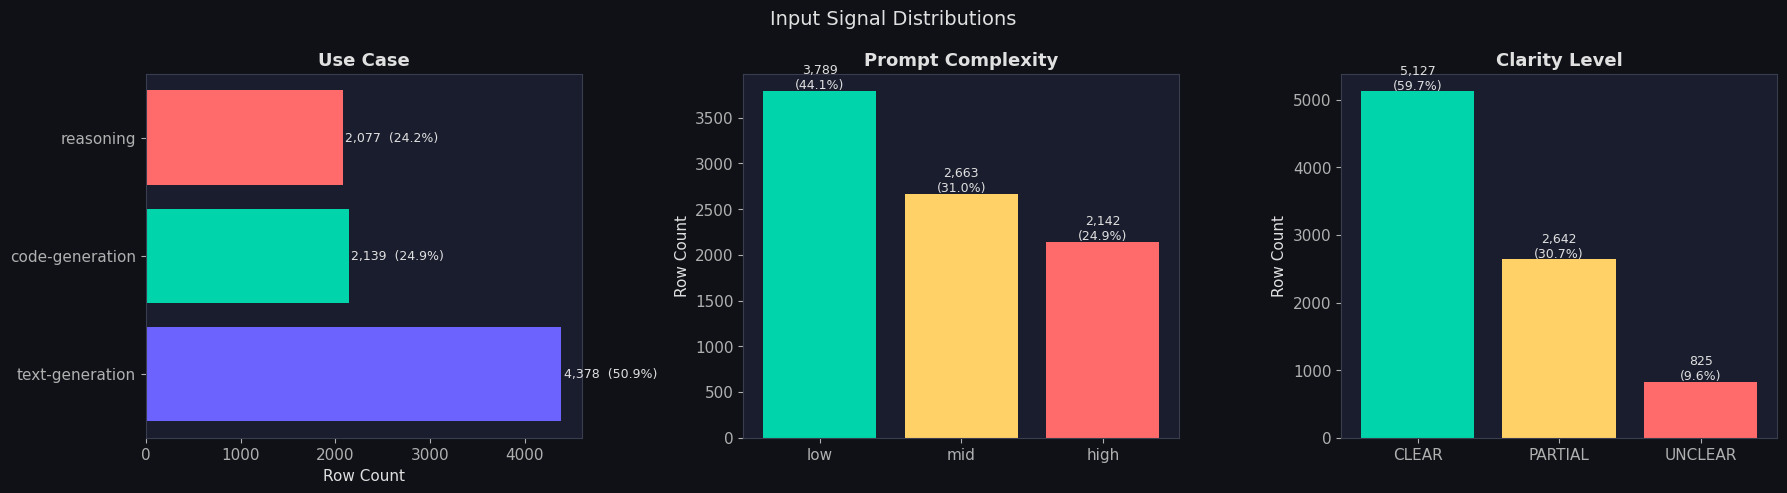

In [5]:
# ── 5. Use Case / Complexity / Clarity Distributions ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Input Signal Distributions', fontsize=14)

# Use Case
uc = df['use_case'].value_counts()
axes[0].barh(uc.index, uc.values, color=PALETTE[:len(uc)])
axes[0].set_title('Use Case')
axes[0].set_xlabel('Row Count')
for i, v in enumerate(uc.values):
    axes[0].text(v + 30, i, f'{v:,}  ({v/len(df)*100:.1f}%)', va='center', fontsize=9)

# Complexity
order = ['low', 'mid', 'high']
comp  = df['prompt_complexity'].value_counts().reindex(order, fill_value=0)
bars  = axes[1].bar(comp.index, comp.values, color=[GOOD_COLOR, WARN_COLOR, BAD_COLOR])
axes[1].set_title('Prompt Complexity')
axes[1].set_ylabel('Row Count')
for bar, v in zip(bars, comp.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

# Clarity
clar_order = ['CLEAR', 'PARTIAL', 'UNCLEAR']
clar = df['clarity'].value_counts().reindex(clar_order, fill_value=0)
bars2 = axes[2].bar(clar.index, clar.values, color=[GOOD_COLOR, WARN_COLOR, BAD_COLOR])
axes[2].set_title('Clarity Level')
axes[2].set_ylabel('Row Count')
for bar, v in zip(bars2, clar.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

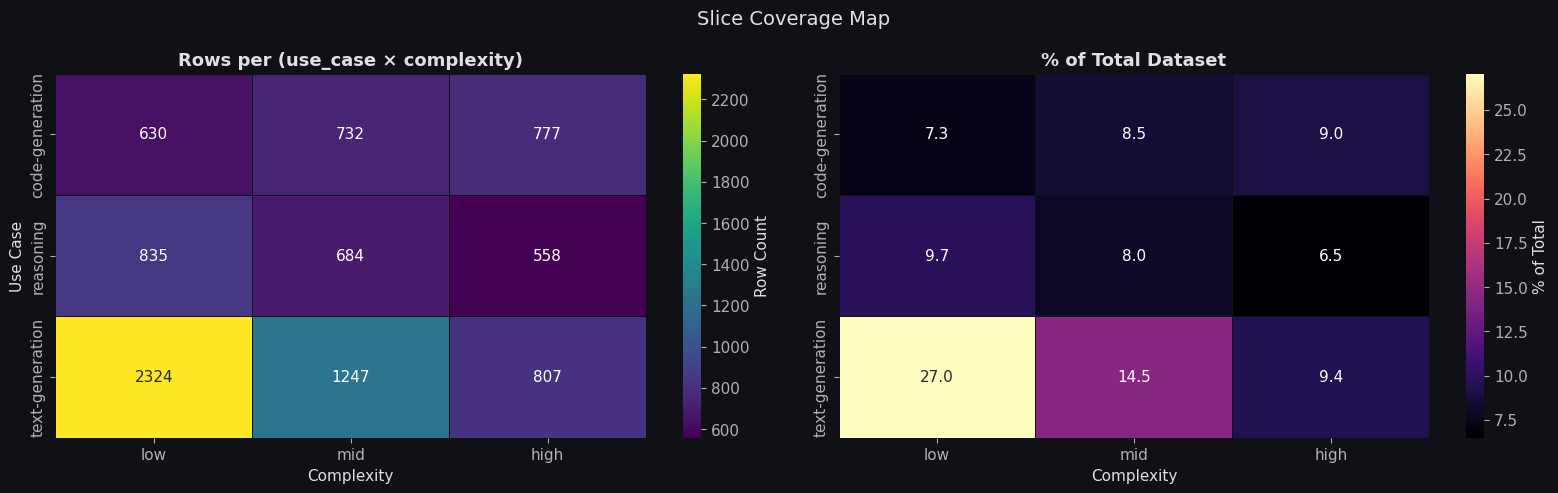


Slice row counts:
prompt_complexity   low   mid  high
use_case                           
code-generation     630   732   777
reasoning           835   684   558
text-generation    2324  1247   807


In [6]:
# ── 6. Cross-tab: Use Case × Complexity ───────────────────────────────────────
cross = pd.crosstab(df['use_case'], df['prompt_complexity'])
cross = cross.reindex(columns=['low','mid','high'], fill_value=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Slice Coverage Map', fontsize=14)

# Heatmap of absolute counts
sns.heatmap(cross, annot=True, fmt='d', cmap='viridis',
            linewidths=0.5, linecolor='#0f1117', ax=ax1,
            cbar_kws={'label': 'Row Count'})
ax1.set_title('Rows per (use_case × complexity)')
ax1.set_xlabel('Complexity')
ax1.set_ylabel('Use Case')

# Heatmap of % of total
cross_pct = cross / cross.values.sum() * 100
sns.heatmap(cross_pct, annot=True, fmt='.1f', cmap='magma',
            linewidths=0.5, linecolor='#0f1117', ax=ax2,
            cbar_kws={'label': '% of Total'})
ax2.set_title('% of Total Dataset')
ax2.set_xlabel('Complexity')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()
print('\nSlice row counts:')
print(cross.to_string())

---
## Section 2 — Model & Provider Analysis

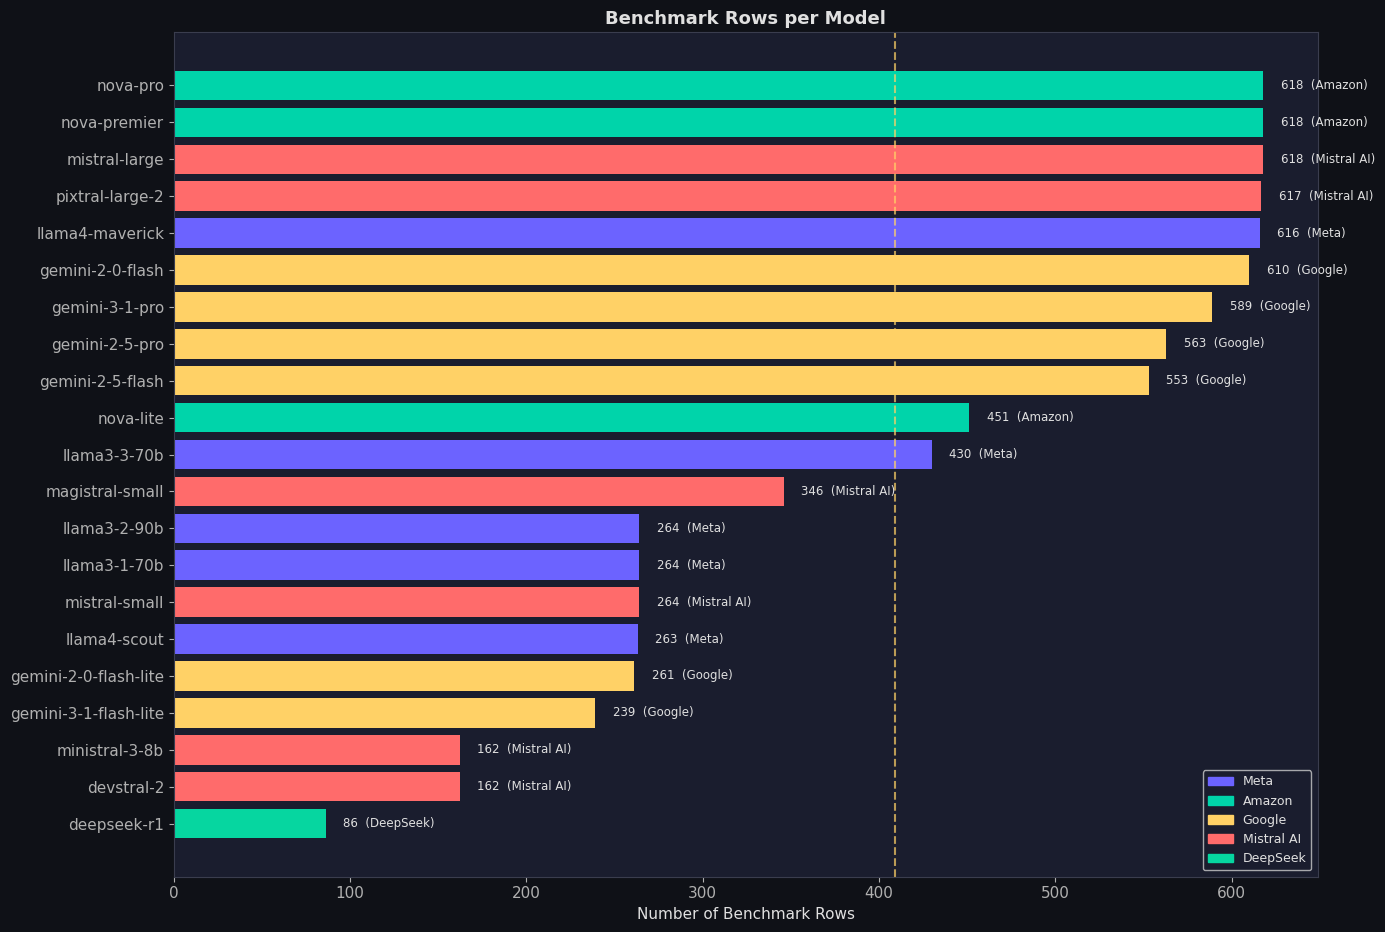

In [7]:
# ── 7. Model Row Count Distribution ──────────────────────────────────────────
model_counts = df.groupby(['model_id','provider']).size().reset_index(name='count')
model_counts = model_counts.sort_values('count', ascending=True)

provider_colors = {
    'Meta': '#6c63ff', 'Amazon': '#00d4aa', 'Google': '#ffd166',
    'Mistral AI': '#ff6b6b', 'DeepSeek': '#06d6a0', 'Anthropic': '#118ab2',
}
colors = [provider_colors.get(p, '#888') for p in model_counts['provider']]

fig, ax = plt.subplots(figsize=(14, max(6, len(model_counts) * 0.45)))
bars = ax.barh(model_counts['model_id'], model_counts['count'], color=colors)
ax.set_xlabel('Number of Benchmark Rows')
ax.set_title('Benchmark Rows per Model')
ax.axvline(model_counts['count'].mean(), color=WARN_COLOR, linestyle='--', alpha=0.7, label=f'Mean = {model_counts["count"].mean():.0f}')

for bar, row in zip(bars, model_counts.itertuples()):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{row.count:,}  ({row.provider})', va='center', fontsize=8.5)

# Legend for providers
from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=p) for p, c in provider_colors.items() if p in model_counts['provider'].values]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

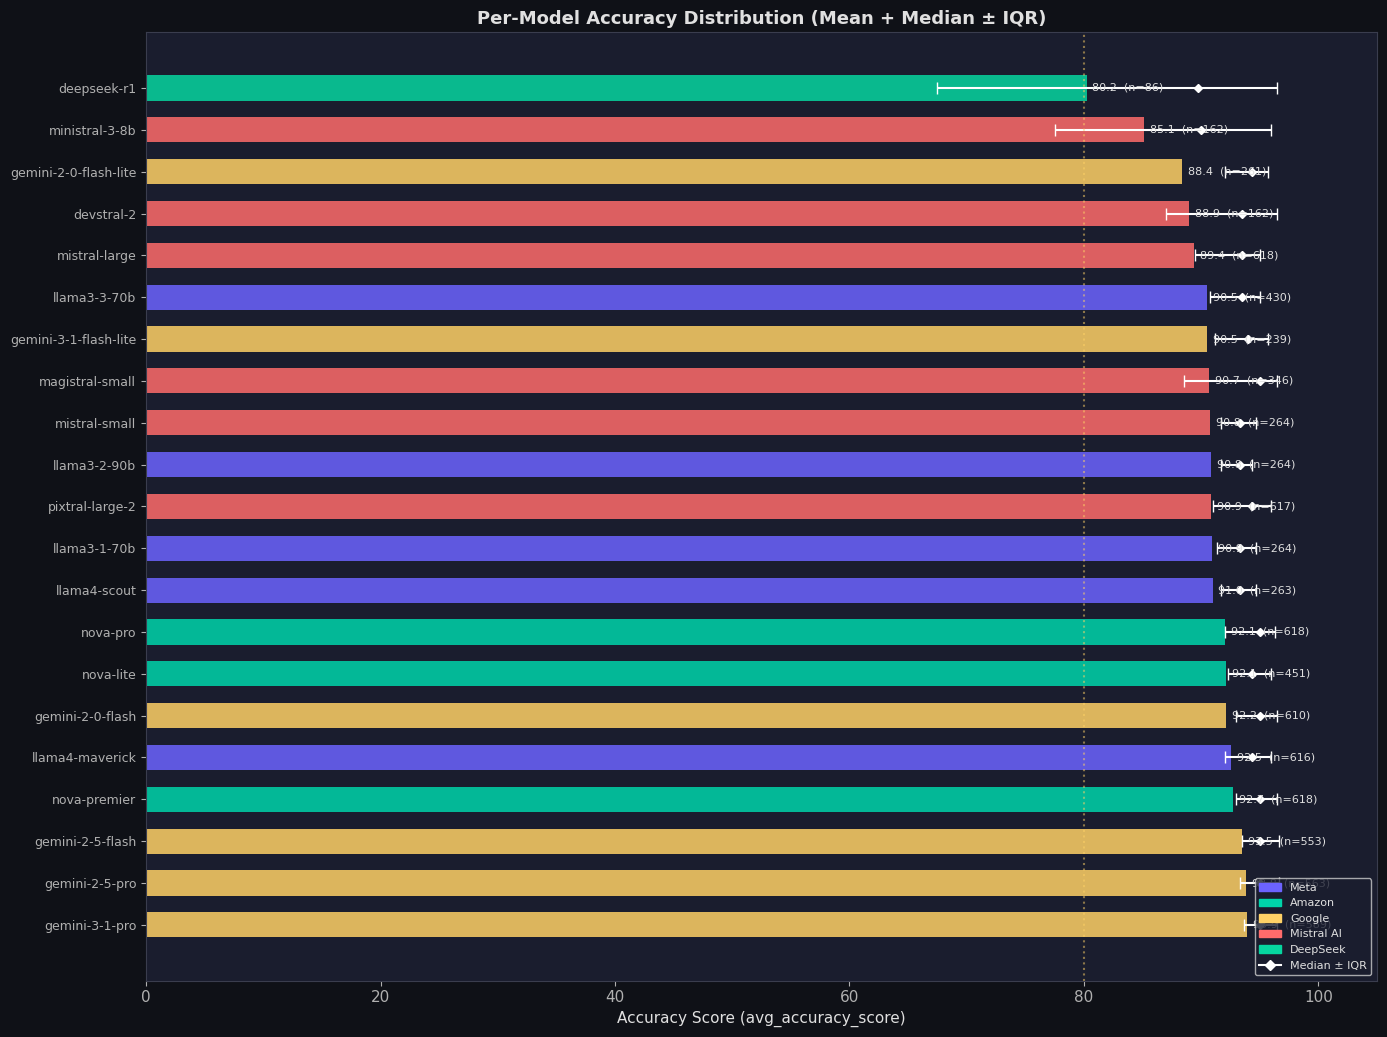

In [8]:
# ── 8. Per-Model Accuracy Summary ─────────────────────────────────────────────
model_stats = (
    df.groupby('model_id')
    .agg(
        n            = ('primary_accuracy', 'count'),
        mean_acc     = ('primary_accuracy', 'mean'),
        median_acc   = ('primary_accuracy', 'median'),
        std_acc      = ('primary_accuracy', 'std'),
        p25_acc      = ('primary_accuracy', lambda x: x.quantile(0.25)),
        p75_acc      = ('primary_accuracy', lambda x: x.quantile(0.75)),
        median_cost  = ('cost', 'median'),
        median_lat   = ('latency_ms', 'median'),
        provider     = ('provider', 'first'),
    )
    .reset_index()
    .sort_values('mean_acc', ascending=False)
)

fig, ax = plt.subplots(figsize=(14, max(6, len(model_stats) * 0.5)))

y_pos  = range(len(model_stats))
colors = [provider_colors.get(p, '#888') for p in model_stats['provider']]

# Error bars (IQR)
xerr_lo = model_stats['median_acc'] - model_stats['p25_acc']
xerr_hi = model_stats['p75_acc']    - model_stats['median_acc']

ax.barh(y_pos, model_stats['mean_acc'], color=colors, alpha=0.85, height=0.6, label='Mean')
ax.errorbar(model_stats['median_acc'], y_pos,
            xerr=[xerr_lo, xerr_hi],
            fmt='D', color='white', capsize=4, ms=4, linewidth=1.5, label='Median ± IQR')

ax.set_yticks(list(y_pos))
ax.set_yticklabels(model_stats['model_id'], fontsize=9)
ax.set_xlabel('Accuracy Score (avg_accuracy_score)')
ax.set_title('Per-Model Accuracy Distribution (Mean + Median ± IQR)')
ax.set_xlim(0, 105)
ax.axvline(80, color=WARN_COLOR, linestyle=':', alpha=0.5, label='80 threshold')

for i, row in enumerate(model_stats.itertuples()):
    ax.text(row.mean_acc + 0.5, i, f'{row.mean_acc:.1f}  (n={row.n})', va='center', fontsize=8)

legend_handles = [Patch(color=c, label=p) for p, c in provider_colors.items() if p in model_stats['provider'].values]
legend_handles += [plt.Line2D([0],[0], marker='D', color='white', label='Median ± IQR', ms=5)]
ax.legend(handles=legend_handles, fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

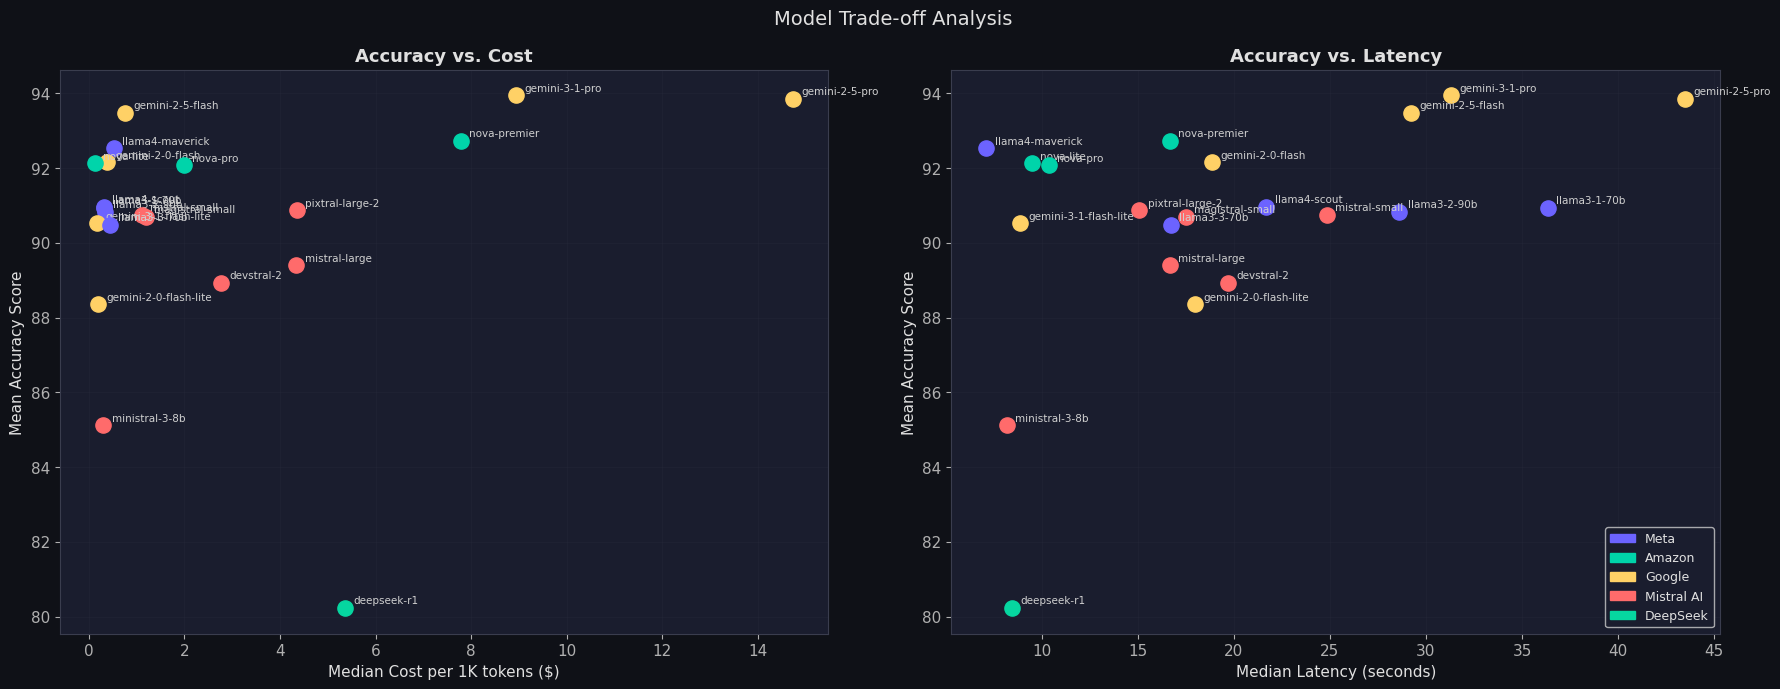

In [9]:
# ── 9. Accuracy × Cost × Latency Scatter (Trade-off View) ─────────────────────
ms = model_stats.copy()
ms['median_lat_s'] = ms['median_lat'] / 1000

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Model Trade-off Analysis', fontsize=14)

# Accuracy vs Cost
for _, row in ms.iterrows():
    c = provider_colors.get(row['provider'], '#888')
    axes[0].scatter(row['median_cost'] * 1000, row['mean_acc'], color=c, s=120, zorder=3)
    axes[0].annotate(row['model_id'],
                     (row['median_cost'] * 1000, row['mean_acc']),
                     textcoords='offset points', xytext=(6, 3),
                     fontsize=7.5, color='#d0d0d0')

axes[0].set_xlabel('Median Cost per 1K tokens ($)')
axes[0].set_ylabel('Mean Accuracy Score')
axes[0].set_title('Accuracy vs. Cost')
axes[0].grid(True, alpha=0.3)

# Accuracy vs Latency
for _, row in ms.iterrows():
    c = provider_colors.get(row['provider'], '#888')
    axes[1].scatter(row['median_lat_s'], row['mean_acc'], color=c, s=120, zorder=3)
    axes[1].annotate(row['model_id'],
                     (row['median_lat_s'], row['mean_acc']),
                     textcoords='offset points', xytext=(6, 3),
                     fontsize=7.5, color='#d0d0d0')

axes[1].set_xlabel('Median Latency (seconds)')
axes[1].set_ylabel('Mean Accuracy Score')
axes[1].set_title('Accuracy vs. Latency')
axes[1].grid(True, alpha=0.3)

legend_handles = [Patch(color=c, label=p) for p, c in provider_colors.items() if p in ms['provider'].values]
axes[1].legend(handles=legend_handles, fontsize=9)

plt.tight_layout()
plt.show()

---
## Section 3 — Accuracy Score Distributions

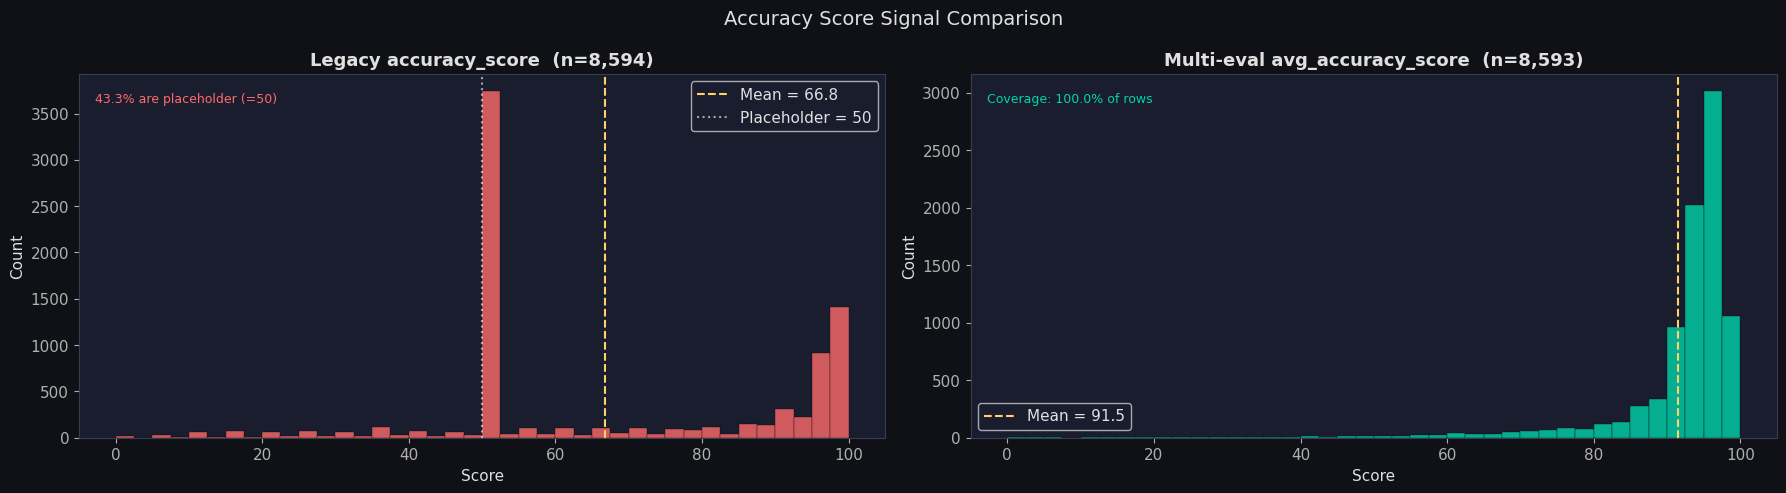

Legacy accuracy_score stats:
count    8594.00
mean       66.80
std        24.41
min         0.00
25%        50.00
50%        50.00
75%        95.00
max       100.00

Multi-eval avg_accuracy_score stats:
count    8593.00
mean       91.47
std        10.52
min         0.00
25%        91.67
50%        94.50
75%        96.00
max       100.00


In [10]:
# ── 10. Legacy vs Multi-Eval Score Distribution ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Accuracy Score Signal Comparison', fontsize=14)

# Legacy accuracy_score
legacy  = df['accuracy_score'].dropna()
axes[0].hist(legacy, bins=40, color=BAD_COLOR, alpha=0.8, edgecolor='black', linewidth=0.3)
axes[0].axvline(legacy.mean(), color=WARN_COLOR, linestyle='--', label=f'Mean = {legacy.mean():.1f}')
axes[0].axvline(50, color='white', linestyle=':', alpha=0.6, label='Placeholder = 50')
axes[0].set_title(f'Legacy accuracy_score  (n={len(legacy):,})')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')
axes[0].legend()
pct_placeholder = (legacy == 50).mean() * 100
axes[0].text(0.02, 0.95, f'{pct_placeholder:.1f}% are placeholder (=50)',
             transform=axes[0].transAxes, fontsize=9, color=BAD_COLOR, va='top')

# avg_accuracy_score
multi = df['avg_accuracy_score'].dropna()
axes[1].hist(multi, bins=40, color=GOOD_COLOR, alpha=0.8, edgecolor='black', linewidth=0.3)
axes[1].axvline(multi.mean(), color=WARN_COLOR, linestyle='--', label=f'Mean = {multi.mean():.1f}')
axes[1].set_title(f'Multi-eval avg_accuracy_score  (n={len(multi):,})')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].text(0.02, 0.95, f'Coverage: {len(multi)/len(df)*100:.1f}% of rows',
             transform=axes[1].transAxes, fontsize=9, color=GOOD_COLOR, va='top')

plt.tight_layout()
plt.show()

print(f'Legacy accuracy_score stats:')
print(legacy.describe().round(2).to_string())
print(f'\nMulti-eval avg_accuracy_score stats:')
print(multi.describe().round(2).to_string())

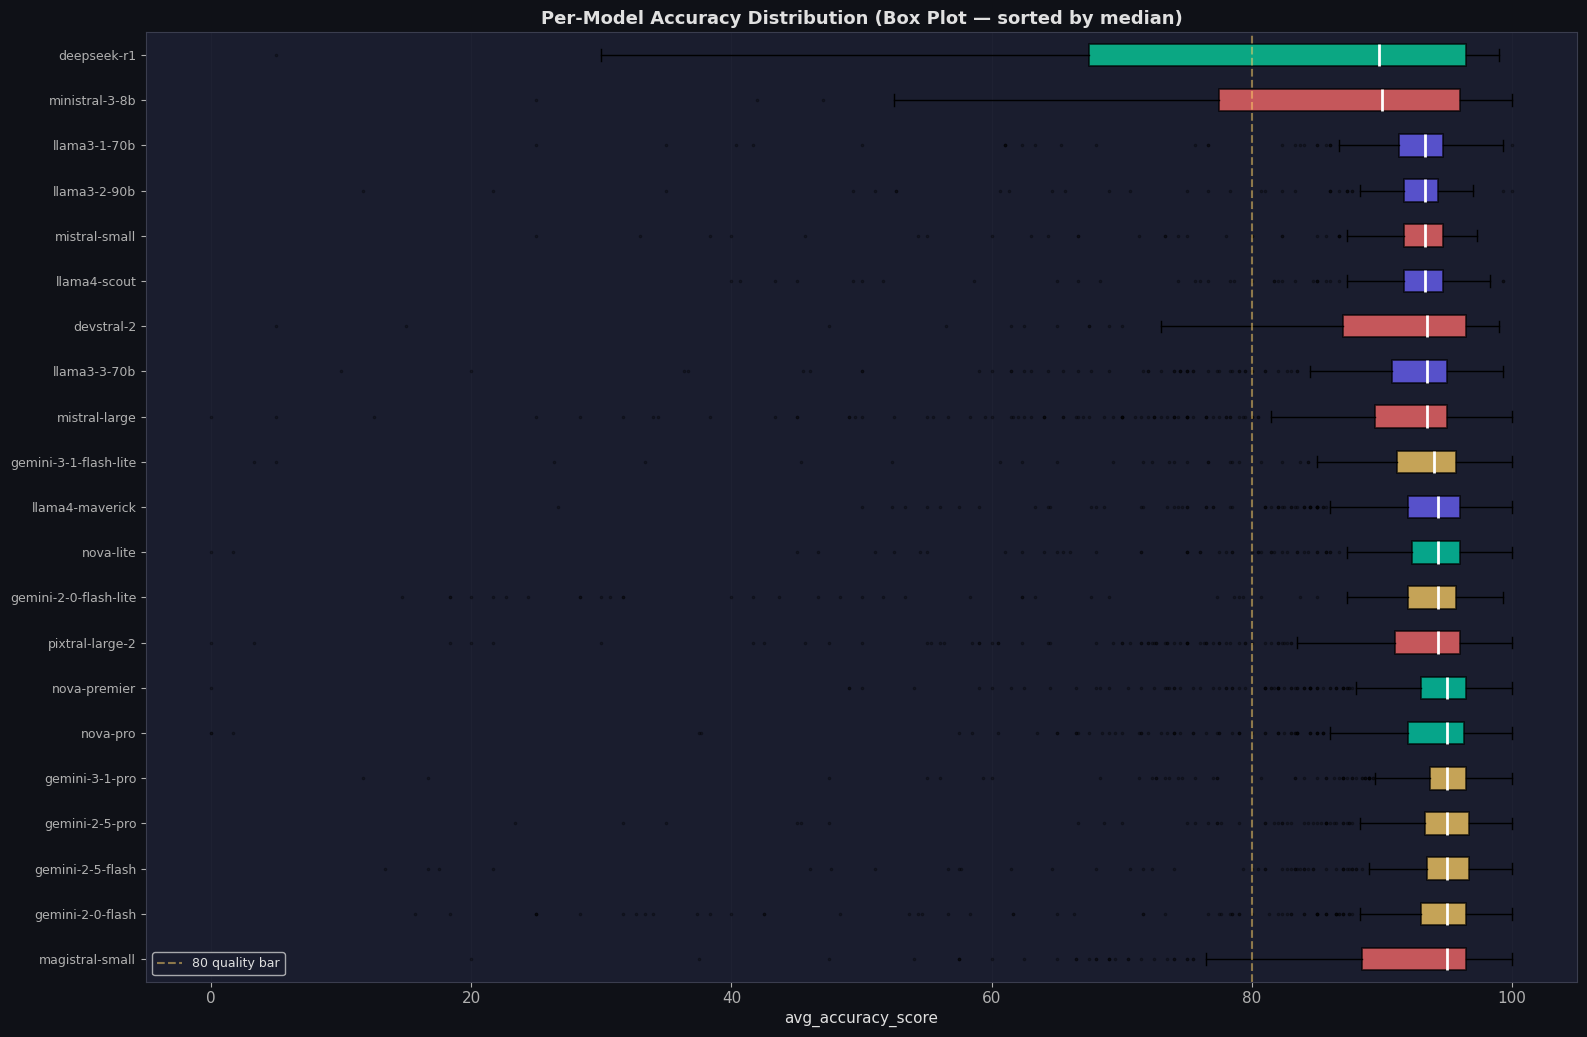

In [11]:
# ── 11. Per-Model avg_accuracy_score Box Plots ────────────────────────────────
model_order = (
    df.groupby('model_id')['avg_accuracy_score']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(16, max(6, len(model_order) * 0.5)))

data_for_box = [
    df[df['model_id'] == m]['avg_accuracy_score'].dropna().values
    for m in model_order
]

bp = ax.boxplot(
    data_for_box,
    vert=False,
    patch_artist=True,
    notch=False,
    boxprops=dict(linewidth=1.2),
    whiskerprops=dict(linewidth=1),
    capprops=dict(linewidth=1),
    medianprops=dict(color='white', linewidth=2),
    flierprops=dict(marker='.', markersize=3, alpha=0.4),
)

for patch, model in zip(bp['boxes'], model_order):
    prov = df[df['model_id'] == model]['provider'].iloc[0]
    patch.set_facecolor(provider_colors.get(prov, '#888'))
    patch.set_alpha(0.75)

ax.set_yticks(range(1, len(model_order) + 1))
ax.set_yticklabels(model_order, fontsize=9)
ax.set_xlabel('avg_accuracy_score')
ax.set_title('Per-Model Accuracy Distribution (Box Plot — sorted by median)')
ax.axvline(80, color=WARN_COLOR, linestyle='--', alpha=0.5, label='80 quality bar')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

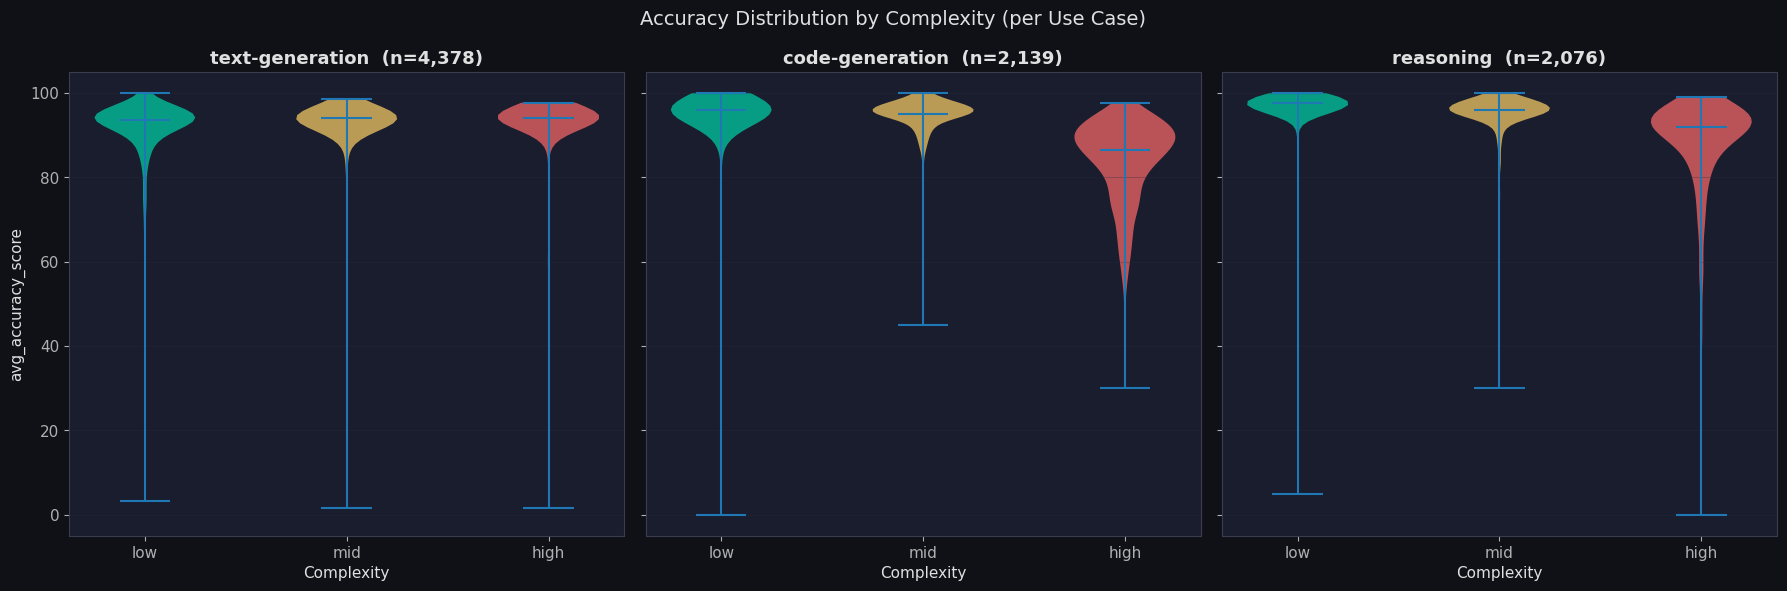

In [12]:
# ── 12. Accuracy by Use Case × Complexity (Violin) ───────────────────────────
df_clean = df.dropna(subset=['avg_accuracy_score','use_case','prompt_complexity'])

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle('Accuracy Distribution by Complexity (per Use Case)', fontsize=14)

for ax, uc in zip(axes, ['text-generation', 'code-generation', 'reasoning']):
    sub = df_clean[df_clean['use_case'] == uc]
    if sub.empty:
        ax.set_title(f'{uc}\n(no data)')
        continue
    groups = [sub[sub['prompt_complexity'] == c]['avg_accuracy_score'].dropna()
              for c in ['low','mid','high']]
    vp = ax.violinplot(groups, positions=[0,1,2], showmedians=True)
    for i, (body, color) in enumerate(zip(vp['bodies'], [GOOD_COLOR, WARN_COLOR, BAD_COLOR])):
        body.set_facecolor(color)
        body.set_alpha(0.7)
    ax.set_xticks([0,1,2])
    ax.set_xticklabels(['low','mid','high'])
    ax.set_xlabel('Complexity')
    ax.set_ylabel('avg_accuracy_score' if ax == axes[0] else '')
    ax.set_title(f'{uc}  (n={len(sub):,})')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Section 4 — Multi-Evaluator Analysis

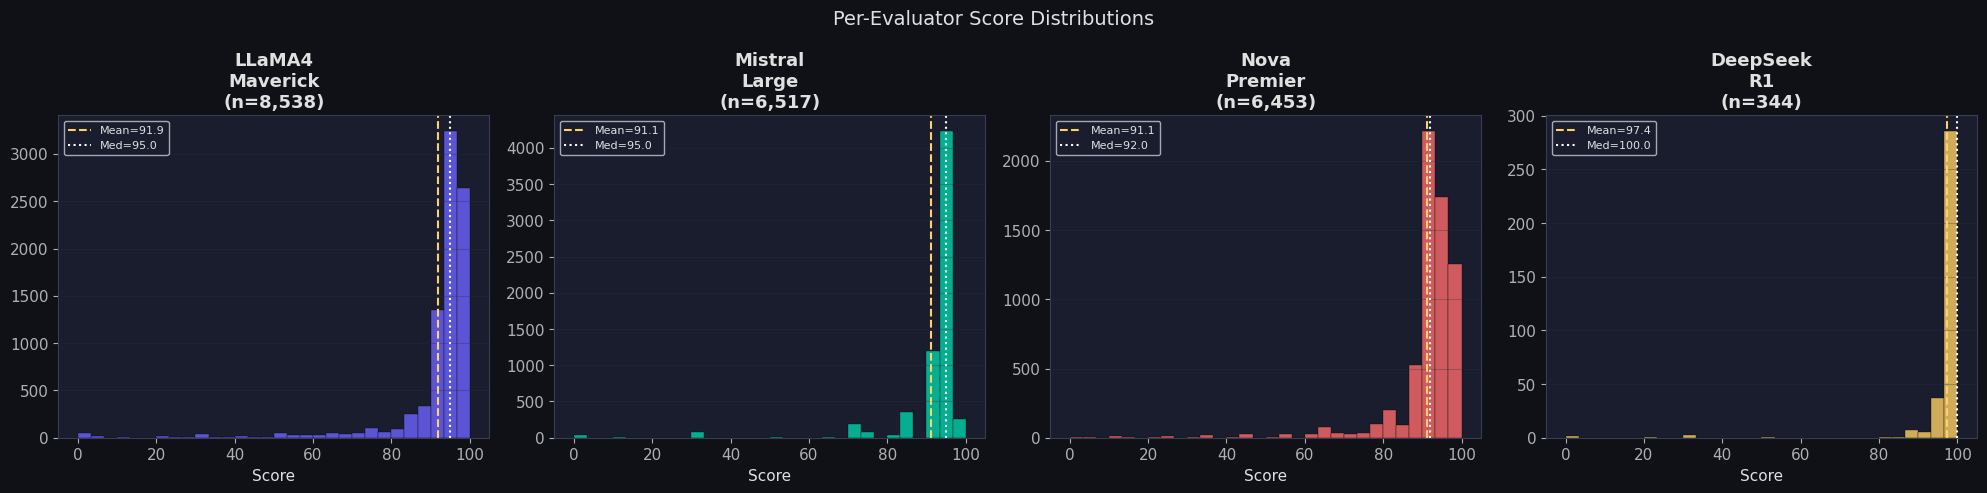


Evaluator score summary:
       LLaMA4\nMaverick  Mistral\nLarge  Nova\nPremier  DeepSeek\nR1
count           8538.00         6517.00        6453.00        344.00
mean              91.89           91.09          91.09         97.35
std               13.21           11.53           9.96         11.38
min                0.00            0.00           0.00          0.00
25%               92.00           90.00          92.00        100.00
50%               95.00           95.00          92.00        100.00
75%               98.00           95.00          95.00        100.00
max              100.00          100.00         100.00        100.00


In [13]:
# ── 13. Per-Evaluator Score Distributions ─────────────────────────────────────
eval_cols = {
    'eval_llama4_maverick_score': 'LLaMA4\nMaverick',
    'eval_mistral_large_score':   'Mistral\nLarge',
    'eval_nova_premier_score':    'Nova\nPremier',
    'eval_deepseek_r1_score':     'DeepSeek\nR1',
}
available_evals = {k: v for k, v in eval_cols.items() if k in df.columns and df[k].notna().sum() > 10}

if not available_evals:
    print('No per-evaluator score columns found — skipping evaluator analysis.')
else:
    fig, axes = plt.subplots(1, len(available_evals), figsize=(5 * len(available_evals), 5), sharey=False)
    if len(available_evals) == 1:
        axes = [axes]
    fig.suptitle('Per-Evaluator Score Distributions', fontsize=14)

    for ax, (col, label), color in zip(axes, available_evals.items(), PALETTE):
        scores = df[col].dropna()
        ax.hist(scores, bins=30, color=color, alpha=0.8, edgecolor='black', linewidth=0.3)
        ax.axvline(scores.mean(),   color=WARN_COLOR, linestyle='--', linewidth=1.5,
                   label=f'Mean={scores.mean():.1f}')
        ax.axvline(scores.median(), color='white',    linestyle=':',  linewidth=1.5,
                   label=f'Med={scores.median():.1f}')
        ax.set_title(f'{label}\n(n={len(scores):,})')
        ax.set_xlabel('Score')
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Summary table
    summary = pd.DataFrame({
        label: df[col].describe().round(2)
        for col, label in available_evals.items()
    })
    print('\nEvaluator score summary:')
    print(summary.to_string())

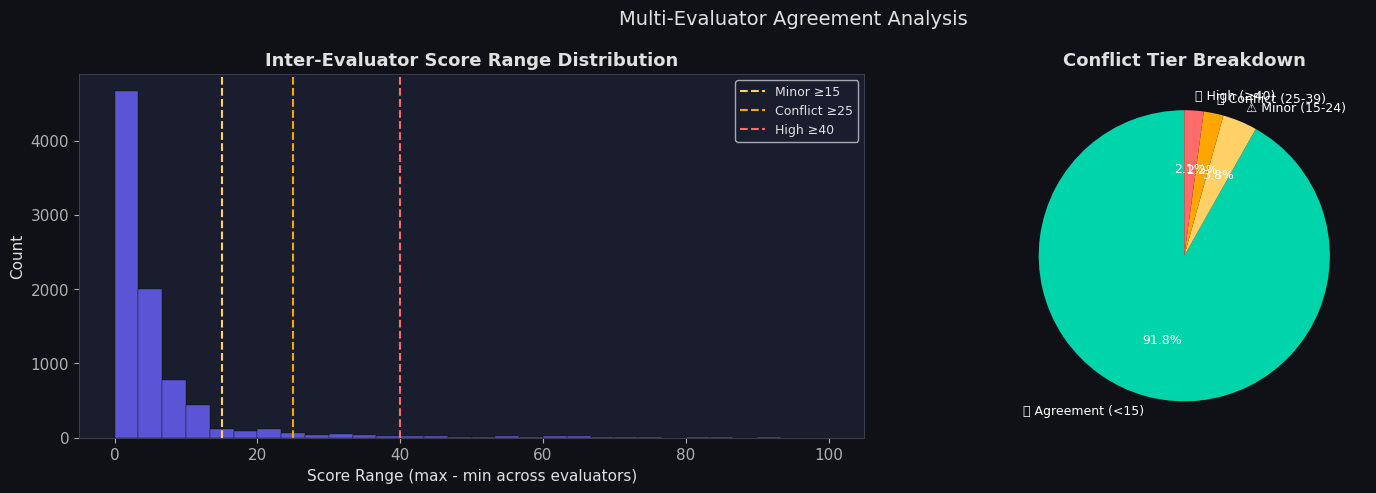


Conflict tier counts:
conflict_tier
✅ Agreement (<15)     7891
⚠️ Minor (15-24)       330
🟠 Conflict (25-39)     188
🔴 High (≥40)           184

Rows with score_range >= 25 (conflict): 372
Rows with score_range >= 40 (high conflict): 184


In [14]:
# ── 14. Evaluator Agreement (Score Range per Row) ─────────────────────────────
eval_col_names = [c for c in eval_cols if c in df.columns]

if len(eval_col_names) >= 2:
    eval_df = df[eval_col_names].dropna(how='all')
    eval_df['score_range'] = eval_df.max(axis=1) - eval_df.min(axis=1)
    eval_df['score_std']   = eval_df[eval_col_names].std(axis=1)
    eval_df['n_evaluators'] = eval_df[eval_col_names].notna().sum(axis=1)

    # Define conflict tiers
    eval_df['conflict_tier'] = pd.cut(
        eval_df['score_range'],
        bins=[-1, 14.9, 24.9, 39.9, 100],
        labels=['✅ Agreement (<15)', '⚠️ Minor (15-24)', '🟠 Conflict (25-39)', '🔴 High (≥40)']
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Multi-Evaluator Agreement Analysis', fontsize=14)

    # Score range histogram
    axes[0].hist(eval_df['score_range'].dropna(), bins=30,
                 color=ACCENT, alpha=0.8, edgecolor='black', linewidth=0.3)
    for thresh, color, label in [(15, WARN_COLOR, 'Minor'), (25, 'orange', 'Conflict'), (40, BAD_COLOR, 'High')]:
        axes[0].axvline(thresh, color=color, linestyle='--', linewidth=1.5, label=f'{label} ≥{thresh}')
    axes[0].set_xlabel('Score Range (max - min across evaluators)')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Inter-Evaluator Score Range Distribution')
    axes[0].legend(fontsize=9)

    # Conflict tier pie
    tier_counts = eval_df['conflict_tier'].value_counts()
    tier_colors = [GOOD_COLOR, WARN_COLOR, 'orange', BAD_COLOR]
    axes[1].pie(
        tier_counts.values,
        labels=tier_counts.index,
        colors=tier_colors[:len(tier_counts)],
        autopct='%1.1f%%',
        startangle=90,
        textprops={'color': 'white', 'fontsize': 9},
    )
    axes[1].set_title('Conflict Tier Breakdown')

    plt.tight_layout()
    plt.show()

    print(f'\nConflict tier counts:')
    print(tier_counts.to_string())
    print(f'\nRows with score_range >= 25 (conflict): {(eval_df["score_range"] >= 25).sum():,}')
    print(f'Rows with score_range >= 40 (high conflict): {(eval_df["score_range"] >= 40).sum():,}')
else:
    print('Not enough evaluator columns for agreement analysis.')

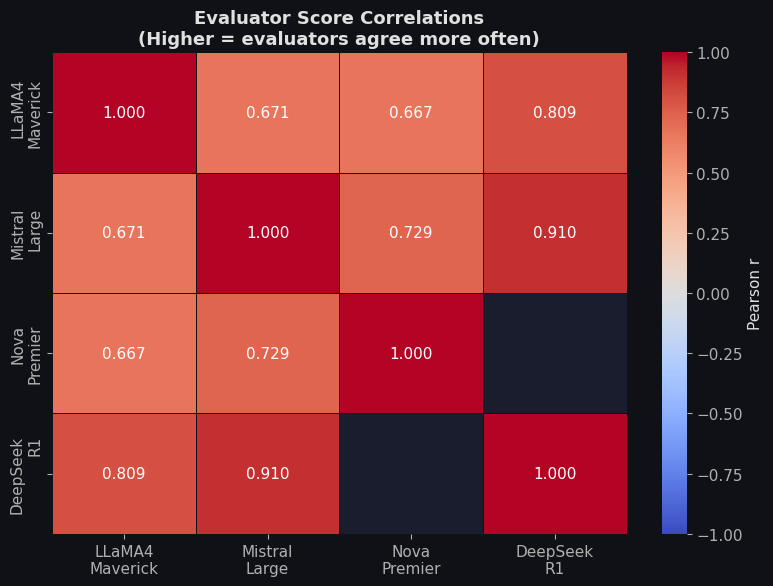

In [15]:
# ── 15. Evaluator Correlation Heatmap ────────────────────────────────────────
if len(eval_col_names) >= 2:
    eval_labels = [eval_cols[c] for c in eval_col_names]
    corr_matrix = df[eval_col_names].corr()
    corr_matrix.index   = eval_labels
    corr_matrix.columns = eval_labels

    fig, ax = plt.subplots(figsize=(8, 6))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
                center=0, vmin=-1, vmax=1,
                linewidths=0.5, linecolor='#0f1117',
                ax=ax, cbar_kws={'label': 'Pearson r'})
    ax.set_title('Evaluator Score Correlations\n(Higher = evaluators agree more often)')
    plt.tight_layout()
    plt.show()

---
## Section 5 — Cost & Latency

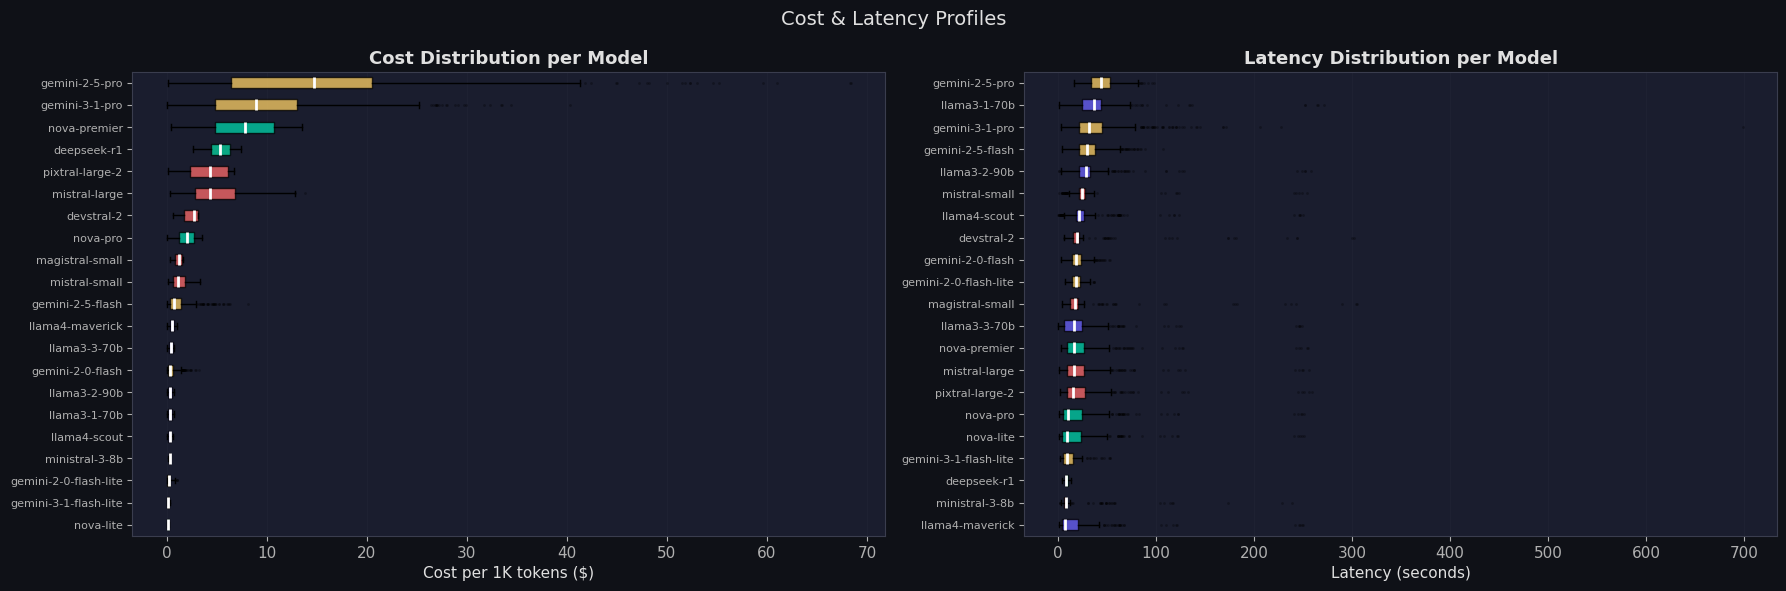

In [16]:
# ── 16. Cost Distribution per Model ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Cost & Latency Profiles', fontsize=14)

model_order_cost = (
    df.groupby('model_id')['cost'].median()
    .sort_values(ascending=True)
    .index.tolist()
)

# Cost box plot
data_cost = [df[df['model_id'] == m]['cost'].dropna().values * 1000 for m in model_order_cost]
bp1 = axes[0].boxplot(data_cost, vert=False, patch_artist=True,
                      medianprops=dict(color='white', linewidth=2),
                      flierprops=dict(marker='.', markersize=2, alpha=0.3))
for patch, m in zip(bp1['boxes'], model_order_cost):
    prov = df[df['model_id'] == m]['provider'].iloc[0]
    patch.set_facecolor(provider_colors.get(prov, '#888'))
    patch.set_alpha(0.75)
axes[0].set_yticks(range(1, len(model_order_cost) + 1))
axes[0].set_yticklabels(model_order_cost, fontsize=8)
axes[0].set_xlabel('Cost per 1K tokens ($)')
axes[0].set_title('Cost Distribution per Model')
axes[0].grid(axis='x', alpha=0.3)

# Latency box plot
model_order_lat = (
    df.groupby('model_id')['latency_ms'].median()
    .sort_values(ascending=True)
    .index.tolist()
)
data_lat = [df[df['model_id'] == m]['latency_ms'].dropna().values / 1000 for m in model_order_lat]
bp2 = axes[1].boxplot(data_lat, vert=False, patch_artist=True,
                      medianprops=dict(color='white', linewidth=2),
                      flierprops=dict(marker='.', markersize=2, alpha=0.3))
for patch, m in zip(bp2['boxes'], model_order_lat):
    prov = df[df['model_id'] == m]['provider'].iloc[0]
    patch.set_facecolor(provider_colors.get(prov, '#888'))
    patch.set_alpha(0.75)
axes[1].set_yticks(range(1, len(model_order_lat) + 1))
axes[1].set_yticklabels(model_order_lat, fontsize=8)
axes[1].set_xlabel('Latency (seconds)')
axes[1].set_title('Latency Distribution per Model')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Section 6 — Data Quality Audit

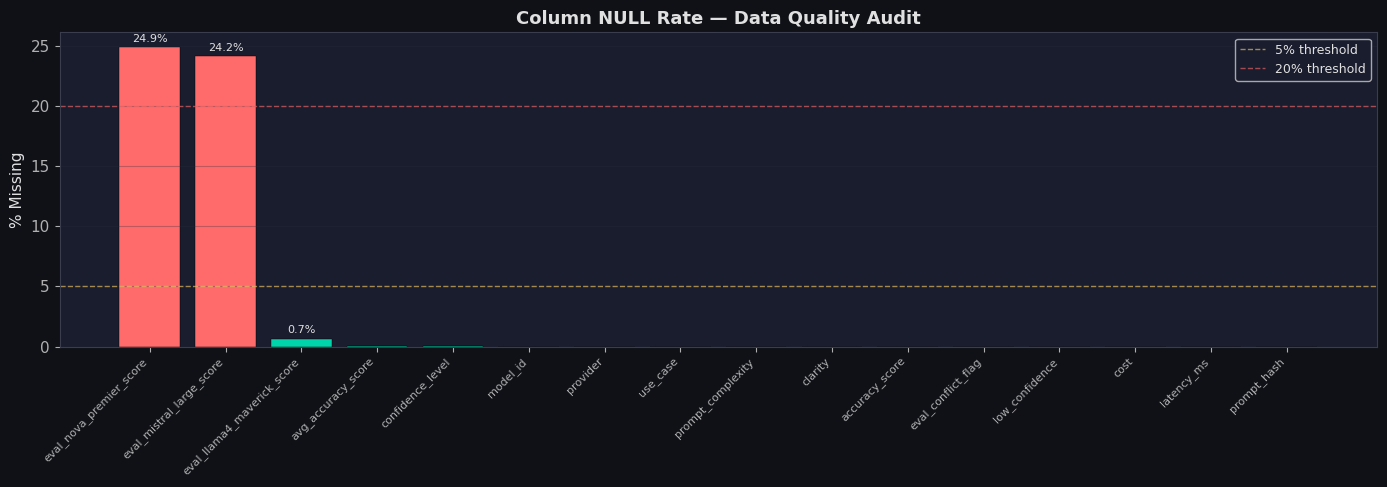


Null counts per column:
model_id                         0
provider                         0
use_case                         0
prompt_complexity                0
clarity                          0
accuracy_score                   0
avg_accuracy_score               1
eval_llama4_maverick_score      56
eval_mistral_large_score      2077
eval_nova_premier_score       2141
eval_conflict_flag               0
low_confidence                   0
confidence_level                 1
cost                             0
latency_ms                       0
prompt_hash                      0


In [17]:
# ── 17. Missing Values Heatmap ────────────────────────────────────────────────
key_cols = [
    'model_id','provider','use_case','prompt_complexity','clarity',
    'accuracy_score','avg_accuracy_score',
    'eval_llama4_maverick_score','eval_mistral_large_score','eval_nova_premier_score',
    'eval_conflict_flag','low_confidence','confidence_level',
    'cost','latency_ms','prompt_hash',
]
key_cols = [c for c in key_cols if c in df.columns]

null_pct = (df[key_cols].isna().mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
colors = [BAD_COLOR if v > 20 else WARN_COLOR if v > 5 else GOOD_COLOR for v in null_pct.values]
bars = ax.bar(null_pct.index, null_pct.values, color=colors, edgecolor='black', linewidth=0.3)

for bar, v in zip(bars, null_pct.values):
    if v > 0.1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('% Missing')
ax.set_title('Column NULL Rate — Data Quality Audit')
ax.set_xticklabels(null_pct.index, rotation=45, ha='right', fontsize=8)
ax.axhline(5, color=WARN_COLOR, linestyle='--', linewidth=1, alpha=0.6, label='5% threshold')
ax.axhline(20, color=BAD_COLOR, linestyle='--', linewidth=1, alpha=0.6, label='20% threshold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('\nNull counts per column:')
print(df[key_cols].isna().sum().to_string())

In [18]:
# ── 18. Data Quality Summary Table ────────────────────────────────────────────
quality = {}

quality['Total rows']                  = len(df)
quality['Has avg_accuracy_score']      = df['avg_accuracy_score'].notna().sum()
quality['Has prompt_hash']             = df['prompt_hash'].notna().sum()
quality['Unique prompt hashes']        = df['prompt_hash'].nunique()
quality['Embeddings in vector store']  = emb_count
quality['KNN coverage (embeddings/%)']=f"{emb_count/max(df['prompt_hash'].nunique(),1)*100:.1f}%"

if 'eval_conflict_flag' in df.columns:
    quality['Has eval_conflict_flag column'] = '✅ Yes'
    quality['Conflict flagged rows']         = int(df['eval_conflict_flag'].sum())
else:
    quality['Has eval_conflict_flag column'] = '❌ No (todo: BUG-007)'

if 'low_confidence' in df.columns:
    quality['Has low_confidence column']    = '✅ Yes'
    quality['Low-confidence rows']          = int(df['low_confidence'].sum())
else:
    quality['Has low_confidence column']    = '❌ No (todo: BUG-007)'

legacy_placeholder = (df['accuracy_score'] == 50).sum() if 'accuracy_score' in df.columns else 0
quality['Legacy placeholder (acc=50)']     = f"{legacy_placeholder:,} ({legacy_placeholder/len(df)*100:.1f}%)"

quality_df = pd.DataFrame.from_dict(quality, orient='index', columns=['Value'])
print('\n=== DATA QUALITY SUMMARY ===')
print(quality_df.to_string())


=== DATA QUALITY SUMMARY ===
                                       Value
Total rows                              8594
Has avg_accuracy_score                  8593
Has prompt_hash                         8594
Unique prompt hashes                     548
Embeddings in vector store               549
KNN coverage (embeddings/%)           100.2%
Has eval_conflict_flag column          ✅ Yes
Conflict flagged rows                    371
Has low_confidence column              ✅ Yes
Low-confidence rows                      220
Legacy placeholder (acc=50)    3,725 (43.3%)


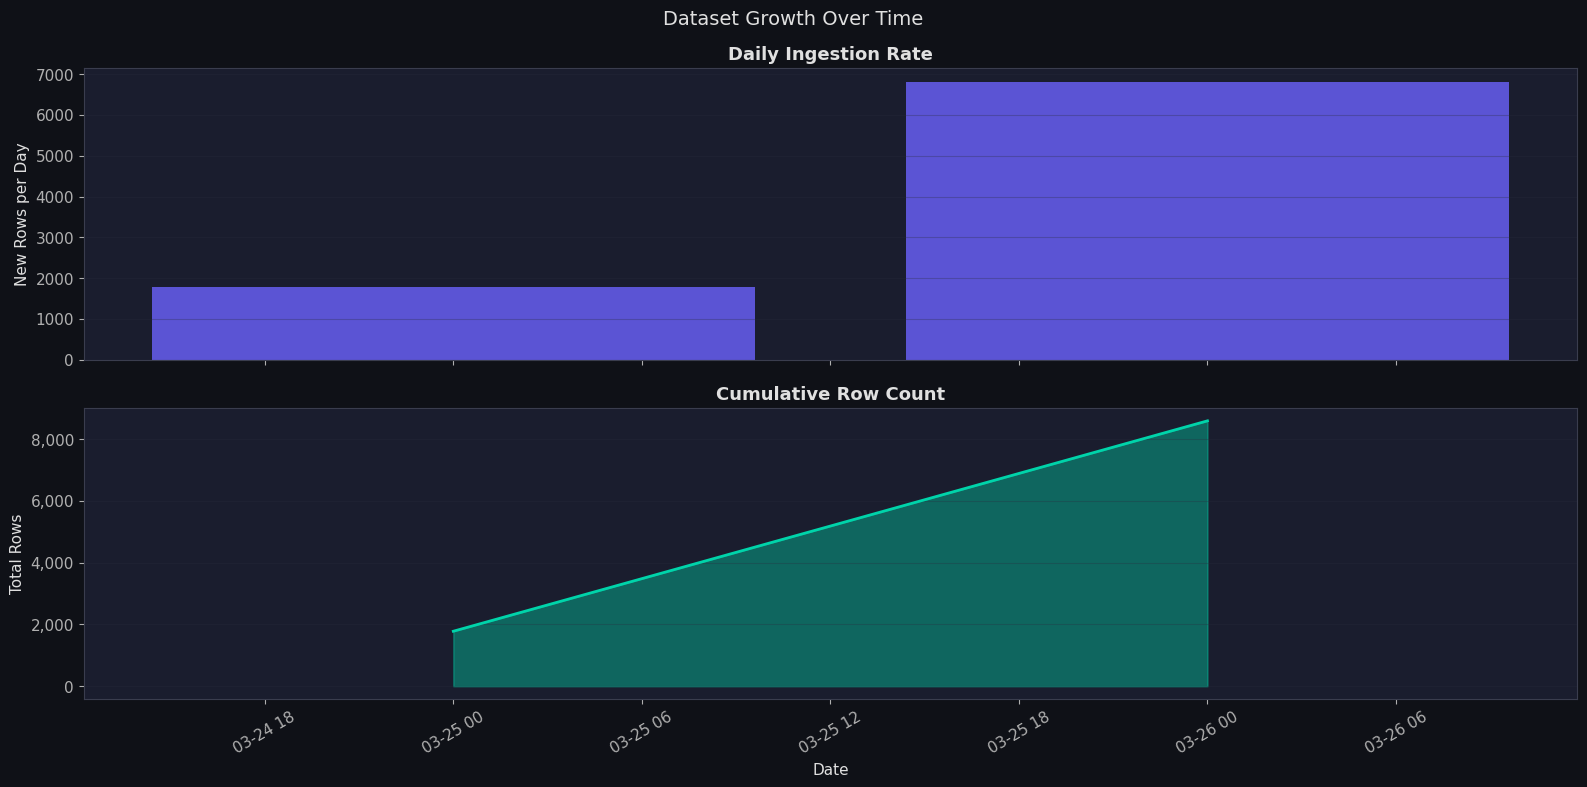

In [19]:
# ── 19. Benchmark Row Growth Over Time ────────────────────────────────────────
if df['created_at'].notna().sum() > 10:
    df_time = df.dropna(subset=['created_at']).copy()
    df_time['date'] = df_time['created_at'].dt.date
    daily = df_time.groupby('date').size().reset_index(name='new_rows')
    daily['cumulative'] = daily['new_rows'].cumsum()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    fig.suptitle('Dataset Growth Over Time', fontsize=14)

    ax1.bar(daily['date'], daily['new_rows'], color=ACCENT, alpha=0.8)
    ax1.set_ylabel('New Rows per Day')
    ax1.set_title('Daily Ingestion Rate')
    ax1.grid(axis='y', alpha=0.3)

    ax2.fill_between(daily['date'], daily['cumulative'], color=GOOD_COLOR, alpha=0.4)
    ax2.plot(daily['date'], daily['cumulative'], color=GOOD_COLOR, linewidth=2)
    ax2.set_ylabel('Total Rows')
    ax2.set_title('Cumulative Row Count')
    ax2.set_xlabel('Date')
    ax2.grid(axis='y', alpha=0.3)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print('Not enough created_at data for time-series plot.')

---
## Section 7 — KNN & Routing Readiness

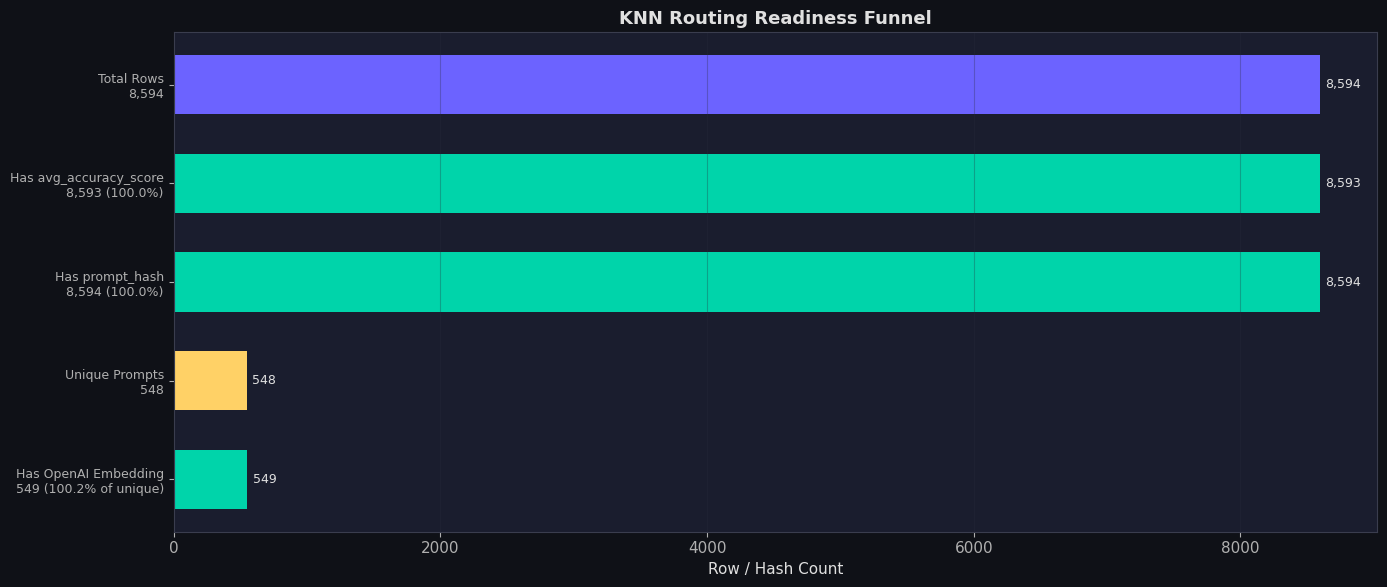

In [20]:
# ── 20. KNN Coverage Funnel ───────────────────────────────────────────────────
total_rows      = len(df)
has_avg_acc     = df['avg_accuracy_score'].notna().sum()
has_hash        = df['prompt_hash'].notna().sum()
unique_hashes   = df['prompt_hash'].nunique()
has_embedding   = emb_count
knn_ready       = has_embedding  # rows that can be found by KNN

funnel_labels = [
    f'Total Rows\n{total_rows:,}',
    f'Has avg_accuracy_score\n{has_avg_acc:,} ({has_avg_acc/total_rows*100:.1f}%)',
    f'Has prompt_hash\n{has_hash:,} ({has_hash/total_rows*100:.1f}%)',
    f'Unique Prompts\n{unique_hashes:,}',
    f'Has OpenAI Embedding\n{has_embedding:,} ({has_embedding/max(unique_hashes,1)*100:.1f}% of unique)',
]
funnel_values = [total_rows, has_avg_acc, has_hash, unique_hashes, has_embedding]
funnel_colors = [ACCENT, GOOD_COLOR, GOOD_COLOR, WARN_COLOR,
                 GOOD_COLOR if has_embedding/max(unique_hashes,1) > 0.9 else WARN_COLOR]

fig, ax = plt.subplots(figsize=(14, 6))
y_pos = range(len(funnel_labels))
bars = ax.barh(list(y_pos), funnel_values, color=funnel_colors, height=0.6)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(funnel_labels, fontsize=9)
ax.set_xlabel('Row / Hash Count')
ax.set_title('KNN Routing Readiness Funnel')
ax.invert_yaxis()
for bar, v in zip(bars, funnel_values):
    ax.text(bar.get_width() + total_rows * 0.005, bar.get_y() + bar.get_height()/2,
            f'{v:,}', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

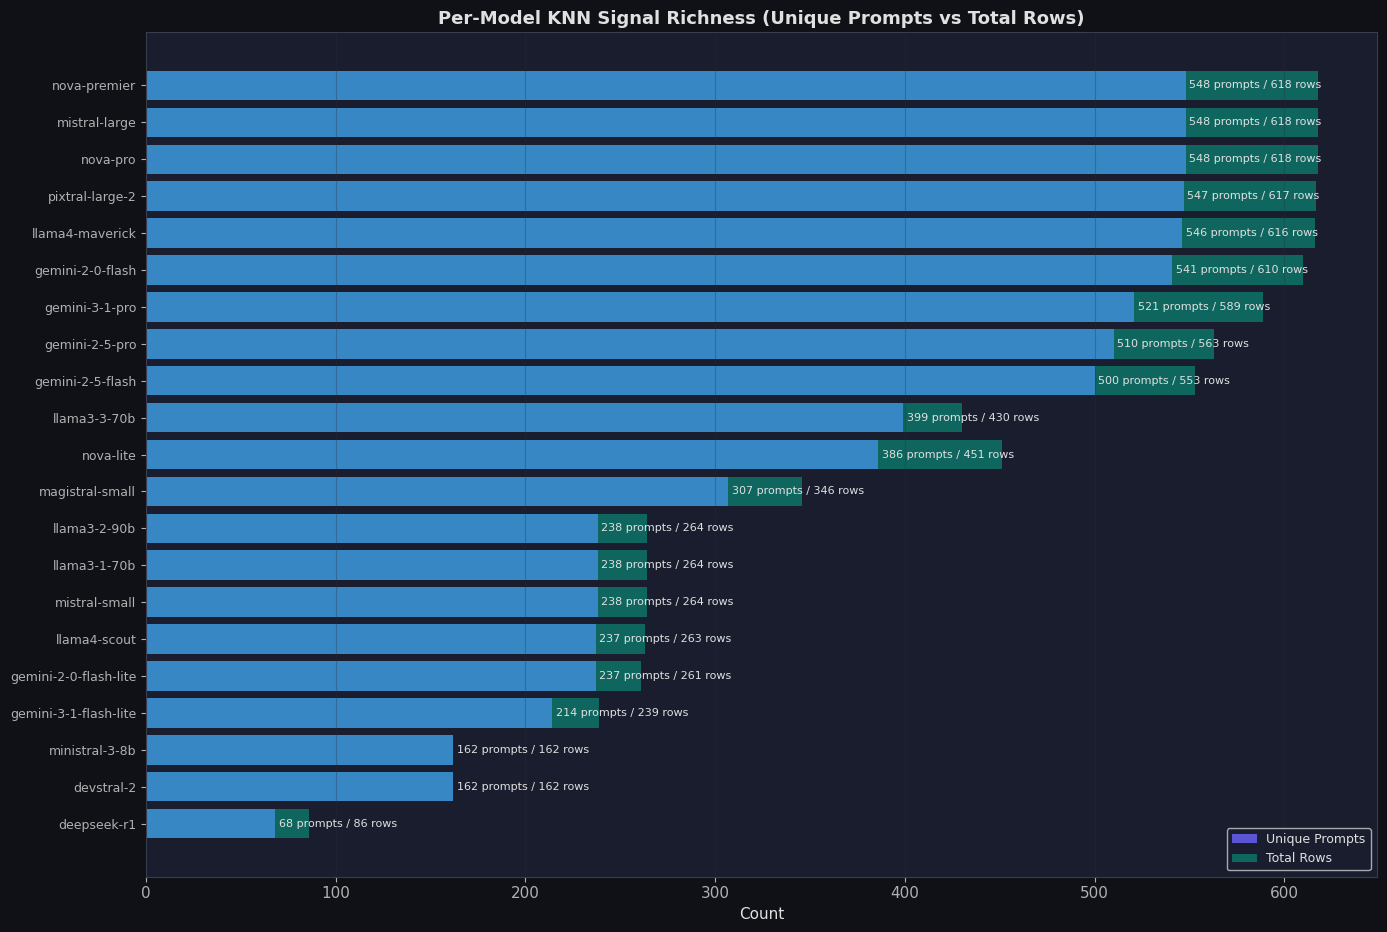

In [21]:
# ── 21. Per-Model KNN Signal Richness ────────────────────────────────────────
# For each model, how many unique prompt_hashes are in benchmark_results?
# More unique hashes per model = richer KNN candidates for that model.

model_hash_richness = (
    df.groupby('model_id')['prompt_hash']
    .agg(['nunique', 'count'])
    .rename(columns={'nunique': 'unique_prompts', 'count': 'total_rows'})
    .reset_index()
    .sort_values('unique_prompts', ascending=True)
)

fig, ax = plt.subplots(figsize=(14, max(6, len(model_hash_richness) * 0.45)))
y_pos = range(len(model_hash_richness))
ax.barh(list(y_pos), model_hash_richness['unique_prompts'], color=ACCENT, alpha=0.8, label='Unique Prompts')
ax.barh(list(y_pos), model_hash_richness['total_rows'],    color=GOOD_COLOR, alpha=0.4, label='Total Rows')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(model_hash_richness['model_id'], fontsize=9)
ax.set_xlabel('Count')
ax.set_title('Per-Model KNN Signal Richness (Unique Prompts vs Total Rows)')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
for i, row in enumerate(model_hash_richness.itertuples()):
    ax.text(row.unique_prompts + 2, i, f'{row.unique_prompts} prompts / {row.total_rows} rows',
            va='center', fontsize=8)
plt.tight_layout()
plt.show()

In [22]:
# ── 22. Final Printout — Routing Readiness Checklist ─────────────────────────
checks = [
    ('avg_accuracy_score coverage > 99%', has_avg_acc / total_rows > 0.99),
    ('prompt_hash coverage = 100%',        has_hash / total_rows >= 0.999),
    ('KNN embedding coverage > 90%',       has_embedding / max(unique_hashes, 1) > 0.90),
    ('eval_conflict_flag column exists',   'eval_conflict_flag' in df.columns),
    ('low_confidence column exists',       'low_confidence' in df.columns),
    ('Unique prompts > 200',               unique_hashes > 200),
    ('No model with < 50 rows',            (model_hash_richness['total_rows'] >= 50).all()),
]

print('\n╔══════════════════════════════════════════════════════════╗')
print('║          LLM Router — Routing Readiness Checklist        ║')
print('╠══════════════════════════════════════════════════════════╣')
for label, passed in checks:
    icon = '✅' if passed else '❌'
    print(f'║  {icon}  {label:<50} ║')
print('╚══════════════════════════════════════════════════════════╝')

passed_count = sum(1 for _, p in checks if p)
print(f'\n{passed_count}/{len(checks)} checks passed.')
if passed_count == len(checks):
    print('🟢 System is KNN-ready.')
elif passed_count >= len(checks) - 2:
    print('🟡 System is mostly ready — fix remaining items.')
else:
    print('🔴 System needs work before KNN is reliable.')


╔══════════════════════════════════════════════════════════╗
║          LLM Router — Routing Readiness Checklist        ║
╠══════════════════════════════════════════════════════════╣
║  ✅  avg_accuracy_score coverage > 99%                  ║
║  ✅  prompt_hash coverage = 100%                        ║
║  ✅  KNN embedding coverage > 90%                       ║
║  ✅  eval_conflict_flag column exists                   ║
║  ✅  low_confidence column exists                       ║
║  ✅  Unique prompts > 200                               ║
║  ✅  No model with < 50 rows                            ║
╚══════════════════════════════════════════════════════════╝

7/7 checks passed.
🟢 System is KNN-ready.
